# MeanShift 추적 실습


- 색상기반 객체 추적
- 비슷한 색상 가진 영역 자동으로 따라가기
- 색상분포(히스토그램)를 기반 객체 추적
- 확률이 높은 방향으로 윈도우 이동 >> 최적 위치(x,y) 찾기
- 실시간 추적에 적합(아주 빠름)

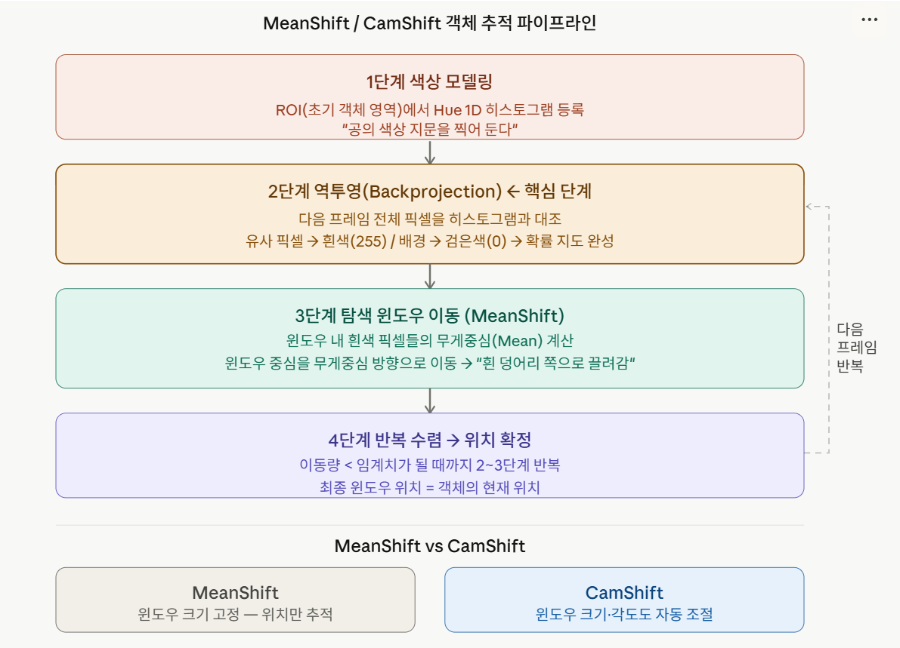

In [4]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow # cv2.imshow (colab용)
import time

# 변수 초기 설정
roi_hist = None
# 추적 대상 객체의 정규화된 히스토그램 저장 변수 (초기값 : None)
# roi(Region of Interest 관심영역) histogram 변수

win_name = 'MeanShift Tracking' # 화면 표시 창(팝업창) 이름

# MeanShift/CamShift 중지 요건 (Termination Criteria)
# (오차(EPS) 또는 반복 횟수(COUNT) 중 하나라도 충족되면 중지)
# 최대 반복 횟수: 10, 허용 오차: 1.0

# 최대 10번 반복하거나 이동거리 기준으로 1pixel 미만이면 수렴(이 중 하나만 만족해도 종료)
termination = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1.0)    # (criteria_type, maxCount, epsilon)

# 추적 대상 영역 (바운딩 박스) 좌표를 저장할 전역 변수
# Colab에서는 cv2.selectROI를 사용할 수 없으므로, 초기 값을 하드코딩합니다.
# NOTE: 이 값을 수정하여 추적할 객체의 초기 위치와 크기를 설정할 수 있습니다.
# (x, y) = 시작 좌표, (w, h) = 너비, 높이

x, y, w, h = 1150, 400, 100, 100

In [5]:
# 비디오 캠쳐 설정
video_path = '/content/drive/MyDrive/컴퓨터비전_응용/data/newyork.mp4'

In [8]:
cap = cv2.VideoCapture(video_path)
delay = int(1000/24) # delay 설정 (약 41ms)

if not cap.isOpened():
    print('오류 발생: 비디오 파일을 열 수 없습니다. 파일 업로드했는지 확인해 주세요')
    exit()

# frame 처리 개수 제한, 출력 주기 설정
frame_count = 0
MAX_FRAME_TO_PROCESS = 150  # 최대 150 프레임(이미지 150장) 만 처리
DISPLAY_EVERY_N_FRAMES = 20 # 20 프레임마다 결과 출력

print(f'MeanShift 추적 시작(최대 {MAX_FRAME_TO_PROCESS} 프레임, {DISPLAY_EVERY_N_FRAMES} 프레임마다 출력)' )

MeanShift 추적 시작(최대 150 프레임, 20 프레임마다 출력)


In [12]:
# 첫 프레임에서 ROI 히스토그램 등록
ret, frame = cap.read()
if not ret:
    print('오류 발생: 첫 프레임을 읽을 수 없습니다.')
    exit()

# 초기 추적 대상 영역(ROI) 추출
roi = frame[y:y+h, x:x+w]
# ex) frame[100:200, 100:250]
# >>> frame[세로 길이, 가로길이] >> frame[100,150] >> 100*150 크기 이미지

# ROI를 HSV 컬러로 변경(H: 색상, S: 채도, V: 명도)
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

# ROI의 H(색상) 채널에 대한 히스토그램 계산
roi_hist = cv2.calcHist([roi_hsv], [0], None, [180], [0, 180])
# [0] : H 채널만 사용 (0번 채널)
# [180]: bin 개수 (히스토그램 구간 개수) 180개 bin
#  None  마스크 >> 전체 사용
# [0, 180]: H 채널 범위 (0도~180도)

# 히스토그램 정규화(최소 0, 최대 255)
# 왜 해요? 역투영(back projection) >> grayscale 이미지 표현
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)
# roi_hist(first): 입력 데이터 (ROI 영역 색상 히스토그램-색 분포 데이터)
# roi_hist(second): 변환된 결과 덮어쓰기 (정규화된 결과>>기존 배열에 직접 수정)

print(f'초기 추적 대상 영역 설정 완료: x = {x}, y = {y}, w = {w}, h = {h}')

초기 추적 대상 영역 설정 완료: x = 1150, y = 400, w = 100, h = 100


역투영 (BACK-PROJECTION)(***)
-  이 픽셀이 가진 색상이 내가 찾는 색상일 확률은?


- 그럼 어떻게 하나?
  - 현재 픽셀의 h(hue) 값 확인 (예: 30도)
  - ROI(관심영역) 히스토그램에서 30도가 얼마나 나오는지(빈도) 확인
  - 그 빈도를 픽셀값으로 설정
  - 그 결과, 밝을 수록 유사한 색상이다라고 간주


In [16]:
# 비디오 처리 루프
while cap.isOpened() and frame_count < MAX_FRAME_TO_PROCESS:
    ret, frame = cap.read()
    if not ret:
        break

    img_draw = frame.copy()
    # 원본 이미지(frame) 위에 추적한 결과를 그리기 위해 복사

    # 전체 영상 BGR >> HSV 컬러 변환
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # 전체 영상에 대해 ROI 히스토그램 역투영(Back projection)   **중요**
    dst = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)
    # dst : 각 픽셀이 ROI 색상과 얼마나 유사한지 나타내는 확률맵이 된다. (0-255)
    # [0] : H(색상) 채널 사용
    # [0-180] : H 채널 범위
    # 1 : 결과물(dst) 크기 조절 비율(scale)

    # 역투영 결과(dst)와 이진 추적 위치로 평균 이동(Mean Shift) 추적 실행
    ret, (x, y, w, h) = cv2.meanShift(dst, (x, y, w, h), termination)
    # ret : 반복횟수, (x, y, w, h) 새로운 추적 위치

    # 새로운 위치에 초록색 사각형 표시
    cv2.rectangle(img_draw, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # 컬러 영상(추적 결과)과 역투영 영상(dst) 좌우로 통합하여 출력
    # dst는 gray(확률맵) >> cv2.cvtColor()로 변환하여 합쳐줌
    # 컬러 영상과 흑백 영상 같이 붙여서 출력하기
    result = np.hstack((img_draw, cv2.cvtColor(dst, cv2.COLOR_GRAY2BGR)))

    # 특정 간격의 프레임만 표시
    if frame_count % DISPLAY_EVERY_N_FRAMES == 0:
        print(f'Frame {frame_count} MeanShift 출력 결과')
        cv2_imshow(result)      # 추적 결과 프레임 표시
        time.sleep(1)           # 출력이 빠르게 지나가는 것을 방지하기 위해 잠시 대기

    frame_count += 1

# 종료 및 정리
cap.release()
# cv2.distroyAllWindows()
# 로컬에서 팝업창 자동으로 닫기

Output hidden; open in https://colab.research.google.com to view.